# Fine-Tune Open Weight Language Models for Function Calling in Strands Agents

[![License](https://img.shields.io/badge/License-Apache%202.0-blue.svg)](https://opensource.org/licenses/Apache-2.0)
[![Python 3.10+](https://img.shields.io/badge/python-3.10+-blue.svg)](https://www.python.org/downloads/)

## Introduction

This notebook demonstrates how to fine-tune small language models (1-3B parameters) for reliable function calling in edge environments. We leverage optimized training pipelines to achieve 2-5x faster training with 50% less memory usage compared to standard implementations.

Function calling, also known as tool use, enables language models to interact with external systems through structured API calls. This is critical for edge deployment where models must control physical devices, query databases, or invoke services with high reliability.

### The Problem We're Solving

Edge devices in vehicles and industrial settings need AI assistants that can:
- **Understand natural language**: "It's too hot" → climate control
- **Execute actions locally**: No cloud dependency for critical controls
- **Work with limited resources**: 2-4GB RAM, no GPU required
- **Maintain high accuracy**: Safety-critical operations demand reliability

### Our Solution: Fine-Tuned Tool Calling

Instead of using a general-purpose model, we specialize Qwen3-1.7B for specific tools:

```mermaid
graph LR
    A[User Input:<br/>'Set the temperature to 72 degrees'] --> B[Model Recognition:<br/>Intent = climate_control<br/>Parameter = 72]
    B --> C[Strands Format:<br/>toolUse.name: climate_control<br/>toolUse.input.command: 'set to 72']
    C --> D[Agent Execution:<br/>Virtual ECU updates<br/>climate state]
    D --> E[User Feedback:<br/>'Temperature set to 72°F']
    
    style A fill:#e1f5fe
    style B fill:#fff3e0
    style C fill:#f3e5f5
    style D fill:#e8f5e9
    style E fill:#fce4ec
```

### What You'll Learn

- Generate high-quality synthetic training data using teacher-student approaches
- Fine-tune models efficiently using LoRA (Low-Rank Adaptation)
- Quantize models for edge deployment while preserving accuracy
- Benchmark performance improvements systematically
- Deploy models using llama.cpp for production inference

### Understanding Model Quantization

Quantization is the process of reducing numerical precision to compress models while preserving performance. In neural networks, weights and activations typically use 32-bit (FP32) or 16-bit (FP16/BF16) floating-point numbers. Quantization reduces these to 8-bit integers or even 4-bit representations, achieving:

- **Size Reduction**: 4-bit quantization reduces model size by ~75% compared to FP16
- **Speed Improvement**: Integer operations are faster than floating-point on most hardware
- **Memory Efficiency**: Enables deployment on resource-constrained edge devices
- **Minimal Accuracy Loss**: Modern quantization methods preserve >99% of model quality

#### Quantization Methods

**K-means Quantization (K-quants)**: Groups similar weights into clusters, storing cluster indices instead of full values. The 'K' variants (Q4_K_M, Q5_K_M) use different bit allocations for different tensor components.

**Dynamic vs Static**: Dynamic quantization determines scale factors at runtime, while static uses pre-computed values. We use static for predictable edge performance.

**Mixed Precision**: Critical layers (like embeddings) maintain higher precision while less sensitive layers use aggressive quantization.

## Install Dependencies & Build Tools

This section installs all required dependencies and builds llama.cpp for GGUF operations.
Run these cells in order - the complete process may take 5-10 minutes.

### What this installs:
- **Python packages**: PyTorch, transformers, PEFT, GGUF, etc.
- **llama.cpp**: Cloned and compiled for GGUF conversion and inference
- **System tools**: Build essentials, CMake, etc.

### Requirements:
- **GPU**: CUDA-capable GPU recommended for training
- **Memory**: 8GB+ RAM for model operations
- **Storage**: 10GB+ free space for models and tools

### Install System Dependencies

Install build tools and system libraries required for compiling llama.cpp.

In [1]:
# Update package lists and install all system dependencies
!sudo apt-get update -qq
!sudo apt-get install -y build-essential cmake git wget curl pkg-config libssl-dev libcurl4-openssl-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.10ubuntu1).
cmake is already the newest version (3.28.3-1build7).
git is already the newest version (1:2.43.0-1ubuntu7.3).
wget is already the newest version (1.21.4-1ubuntu4.1).
curl is already the newest version (8.5.0-2ubuntu10.6).
pkg-config is already the newest version (1.8.1-2build1).
libssl-dev is already the newest version (3.0.13-0ubuntu3.5).
libcurl4-openssl-dev is already the newest version (8.5.0-2ubuntu10.6).
The following packages were automatically installed and are no longer required:
  gyp javascript-common libcares2 libfile-basedir-perl
  libfile-desktopentry-perl libfile-mimeinfo-perl libio-stringy-perl
  libipc-system-simple-perl libjs-async libjs-events libjs-inherits
  libjs-is-typedarray libjs-prettify libjs-regenerate libjs-source-map
  libjs-sprintf-js libjs-typedarray-to-buffer libnet-dbus-perl libre2-10
  libtie-i

### Install Python Dependencies

Install all required Python packages using uv package manager.

In [2]:
# Install Python dependencies
!cd ../../ && pip install -e .[dev,ml,function-calling]
!pip install ipywidgets  #==8.0.7

Obtaining file:///home/ubuntu/samples-dev/02-samples/14-agentic-ai-at-the-edge
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Cloning https://github.com/westonbrown/sdk-python.git (to revision main) to /tmp/pip-install-knv4lwdn/strands-agents_0cc6eb73061040248df7d5e26c23b3a6
  Running command git clone --filter=blob:none --quiet https://github.com/westonbrown/sdk-python.git /tmp/pip-install-knv4lwdn/strands-agents_0cc6eb73061040248df7d5e26c23b3a6
  Resolved https://github.com/westonbrown/sdk-python.git to commit 11e6c11bda9fd870a31cf95944b104e7cac0f3c3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached torch-2.8.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached torchvision-0.23.0-cp312-cp312-manylinux_2_28_

### Clone llama.cpp Repository

Clone the official llama.cpp repository for GGUF conversion and inference tools.

In [3]:
# Clone llama.cpp if not already present
!if [ ! -d "./llama.cpp" ]; then \
    git clone https://github.com/ggerganov/llama.cpp.git; \
else \
    cd llama.cpp && git pull; \
fi

Cloning into 'llama.cpp'...
remote: Enumerating objects: 60398, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 60398 (delta 19), reused 14 (delta 13), pack-reused 60356 (from 3)
Receiving objects: 100% (60398/60398), 150.46 MiB | 38.53 MiB/s, done.
Resolving deltas: 100% (43852/43852), done.


### Build llama.cpp with CUDA Support

Check for CUDA availability and compile llama.cpp with appropriate optimizations.

In [4]:
# Build llama.cpp with CUDA support if available
!cd llama.cpp && rm -rf build && \
if command -v nvcc &> /dev/null; then \
    cmake -B build -DGGML_CUDA=ON -DCMAKE_BUILD_TYPE=Release -DLLAMA_CURL=OFF; \
    cmake --build build --config Release -j $(nproc); \
else \
    cmake -B build -DCMAKE_BUILD_TYPE=Release -DLLAMA_CURL=OFF; \
    cmake --build build --config Release -j $(nproc); \
fi

-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.43.0") 
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_ARCH: x86
-- Including CPU backend
-- Found OpenMP_C: -fopenmp (found version "4.5") 
-- Found OpenMP_CXX: -fopenmp (found ve

### Verify Installation

Check that all components are properly installed and working.

In [5]:
# Verify Python packages and llama.cpp binaries
from pathlib import Path

# Test key Python imports
try:
    import torch
    import transformers
    import peft
    import gguf
    print("Python packages: All required packages available")
except ImportError as e:
    print(f"Missing package: {e}")

# Check for critical llama.cpp files
llamacpp_dir = Path("./llama.cpp")
build_dir = llamacpp_dir / "build" / "bin"
key_files = [
    build_dir / "llama-server",
    build_dir / "llama-quantize", 
    llamacpp_dir / "convert_hf_to_gguf.py"
]

missing_files = [f for f in key_files if not f.exists()]
if missing_files:
    print(f"Missing files: {[str(f) for f in missing_files]}")
else:
    print("llama.cpp: All required binaries and scripts available")

Python packages: All required packages available
llama.cpp: All required binaries and scripts available


In [6]:
# Imports
import json
import torch
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Data Preparation

### Optional: Generate Custom Training Data

This notebook includes pre-generated training data (651 examples) and test data (266 examples) that follows the correct format for function calling. However, if you want to generate additional training data or customize the examples, you can use the built-in data generator.

**Requirements for data generation:**
- AWS Bedrock access with Claude 3.5 Sonnet (for high-quality synthetic data)
- Proper AWS credentials configured
- Bearer token (if required by your setup)

**Skip this cell if you want to use the existing training data.**

In [7]:
# # OPTIONAL: Generate additional training data using AWS Bedrock
# # Uncomment the lines below if you want to generate custom training data

# from utils.data_generator import DataGenerator, ToolRegistry
# import os

# # Set your AWS Bearer Token
# os.environ['AWS_BEARER_TOKEN_BEDROCK'] = 'your_token_here'

# # Generate training data
# generator = DataGenerator()
# generator.generate_dataset(
#     num_examples=1000,
#     output_path="data/train.jsonl", 
#     format_for_training=True
# )

# # Generate test data  
# generator.generate_dataset(
#     num_examples=200,
#     output_path="data/test.jsonl",
#     format_for_training=True
# )

In [8]:
# Load training data
train_path = Path('data/train.jsonl')
test_path = Path('data/test.jsonl')

train_texts = []
with open(train_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        train_texts.append(data['text'])

test_texts = []
with open(test_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        test_texts.append(data['text'])

print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

Train: 1000, Test: 200


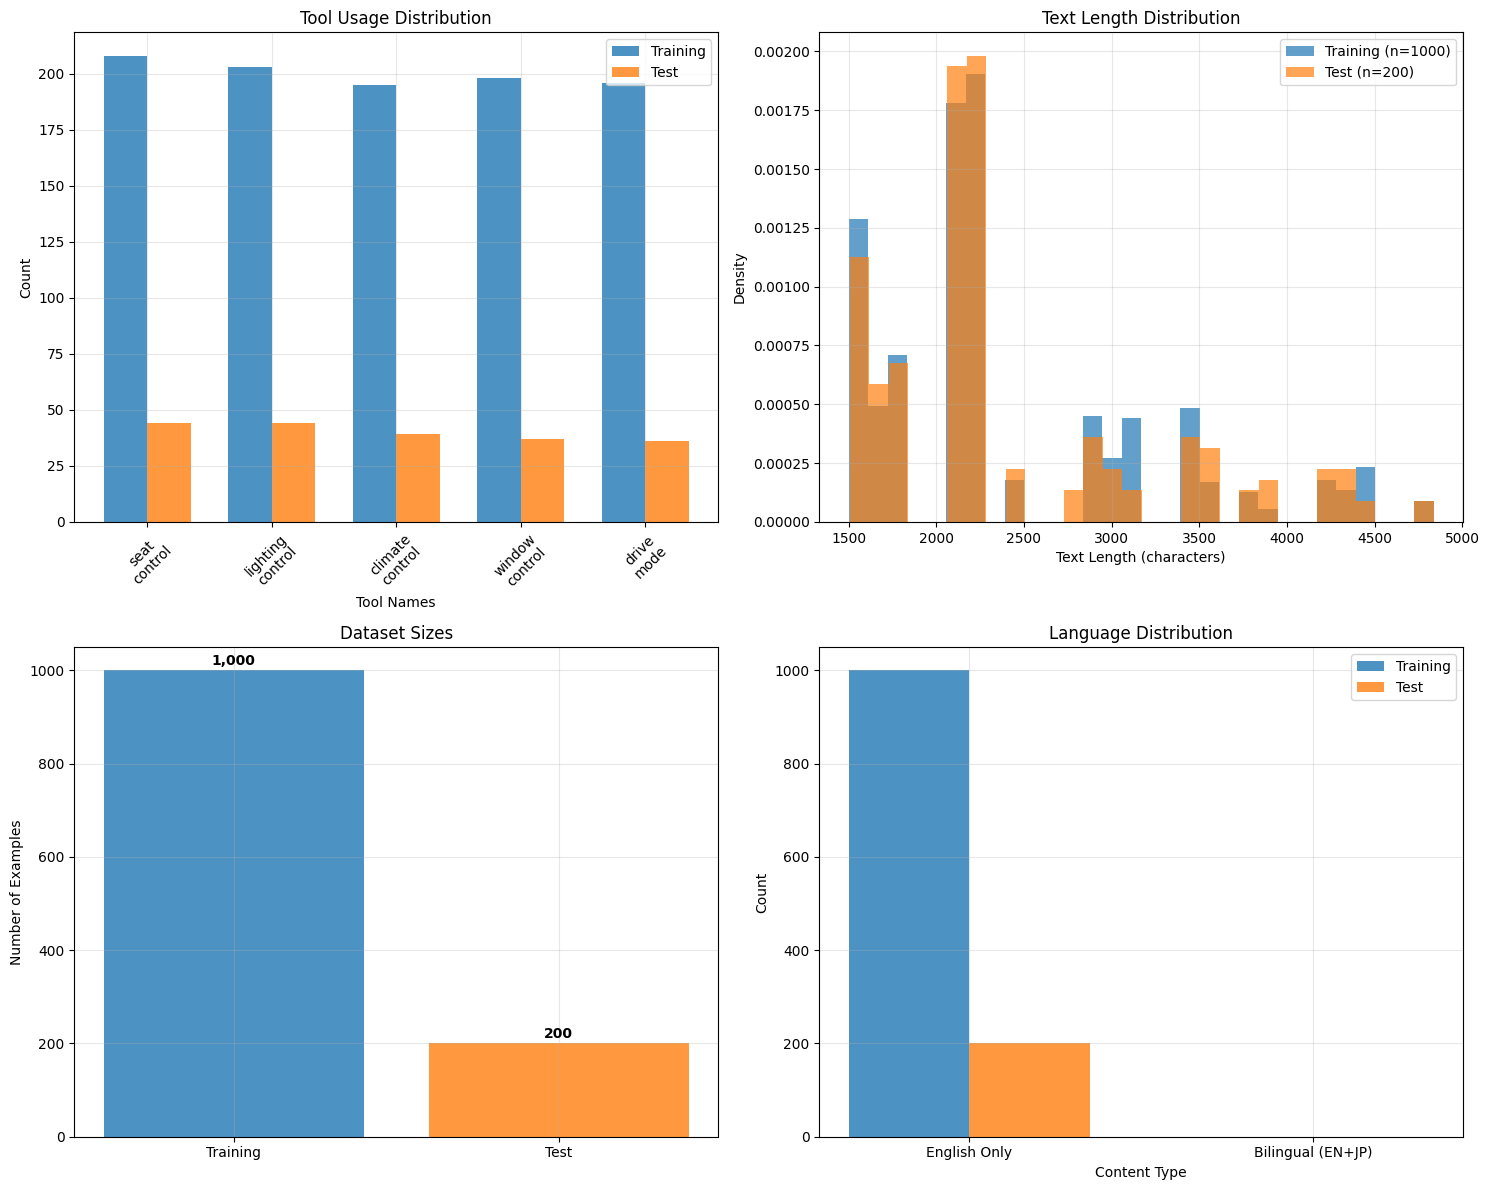

Training: 1,000 examples, 0 bilingual (0.0%)
Test: 200 examples, 0 bilingual (0.0%)
Avg text length - Training: 2419 chars, Test: 2423 chars


In [9]:
# Exploratory Data Analysis of Training and Test Datasets
import matplotlib.pyplot as plt
import re
from collections import Counter

# Extract tool usage and text lengths from datasets
def analyze_dataset(texts, dataset_name):
    tool_counts = Counter()
    text_lengths = []
    bilingual_count = 0
    
    for text in texts:
        # Count tool usage
        tool_match = re.search(r'"name":\s*"([^"]+)"', text)
        if tool_match:
            tool_counts[tool_match.group(1)] += 1
        
        # Text length analysis
        text_lengths.append(len(text))
        
        # Check for Japanese/bilingual content
        if any(ord(char) > 127 for char in text):
            bilingual_count += 1
    
    return tool_counts, text_lengths, bilingual_count

# Analyze both datasets
train_tools, train_lengths, train_bilingual = analyze_dataset(train_texts, "Training")
test_tools, test_lengths, test_bilingual = analyze_dataset(test_texts, "Test")

# Create 4 EDA charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1: Tool Distribution Comparison
tools = list(set(train_tools.keys()) | set(test_tools.keys()))
train_counts = [train_tools.get(tool, 0) for tool in tools]
test_counts = [test_tools.get(tool, 0) for tool in tools]

x = range(len(tools))
width = 0.35
ax1.bar([i - width/2 for i in x], train_counts, width, label='Training', alpha=0.8)
ax1.bar([i + width/2 for i in x], test_counts, width, label='Test', alpha=0.8)
ax1.set_xlabel('Tool Names')
ax1.set_ylabel('Count')
ax1.set_title('Tool Usage Distribution')
ax1.set_xticks(x)
ax1.set_xticklabels([tool.replace('_', '\n') for tool in tools], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Text Length Distribution
ax2.hist(train_lengths, bins=30, alpha=0.7, label=f'Training (n={len(train_texts)})', density=True)
ax2.hist(test_lengths, bins=30, alpha=0.7, label=f'Test (n={len(test_texts)})', density=True)
ax2.set_xlabel('Text Length (characters)')
ax2.set_ylabel('Density')
ax2.set_title('Text Length Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Chart 3: Dataset Size Comparison
datasets = ['Training', 'Test']
sizes = [len(train_texts), len(test_texts)]
colors = ['#1f77b4', '#ff7f0e']
bars = ax3.bar(datasets, sizes, color=colors, alpha=0.8)
ax3.set_ylabel('Number of Examples')
ax3.set_title('Dataset Sizes')
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

# Chart 4: Bilingual Content Analysis
bilingual_data = [
    ['English Only', 'Bilingual (EN+JP)'],
    [len(train_texts) - train_bilingual, train_bilingual],
    [len(test_texts) - test_bilingual, test_bilingual]
]

x = range(len(bilingual_data[0]))
width = 0.35
ax4.bar([i - width/2 for i in x], bilingual_data[1], width, label='Training', alpha=0.8)
ax4.bar([i + width/2 for i in x], bilingual_data[2], width, label='Test', alpha=0.8)
ax4.set_xlabel('Content Type')
ax4.set_ylabel('Count')
ax4.set_title('Language Distribution')
ax4.set_xticks(x)
ax4.set_xticklabels(bilingual_data[0])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Training: {len(train_texts):,} examples, {train_bilingual} bilingual ({train_bilingual/len(train_texts)*100:.1f}%)")
print(f"Test: {len(test_texts):,} examples, {test_bilingual} bilingual ({test_bilingual/len(test_texts)*100:.1f}%)")
print(f"Avg text length - Training: {sum(train_lengths)/len(train_lengths):.0f} chars, Test: {sum(test_lengths)/len(test_lengths):.0f} chars")

## Model Setup

In [10]:
# Load base model
model_name = "Qwen/Qwen3-1.7B"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B parameters")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded: 1.72B parameters


In [11]:
# Configure LoRA
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
model.enable_input_require_grads()

trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030


## Training

In [12]:
# Prepare datasets
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=1024
    )

train_dataset = Dataset.from_dict({"text": train_texts})
test_dataset = Dataset.from_dict({"text": test_texts})

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [13]:
# Training configuration
training_args = TrainingArguments(
    output_dir="./qwen3-function-calling",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=100,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=2e-4,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
)

/tmp/ipykernel_351048/3257573518.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:
# Train the model
trainer.train()
trainer.save_model("./qwen3-function-calling-final")
tokenizer.save_pretrained("./qwen3-function-calling-final")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.117700,0.069700
2,0.030700,0.030941
3,0.021700,0.027421


('./qwen3-function-calling-final/tokenizer_config.json',
 './qwen3-function-calling-final/special_tokens_map.json',
 './qwen3-function-calling-final/chat_template.jinja',
 './qwen3-function-calling-final/vocab.json',
 './qwen3-function-calling-final/merges.txt',
 './qwen3-function-calling-final/added_tokens.json',
 './qwen3-function-calling-final/tokenizer.json')

## Training Results

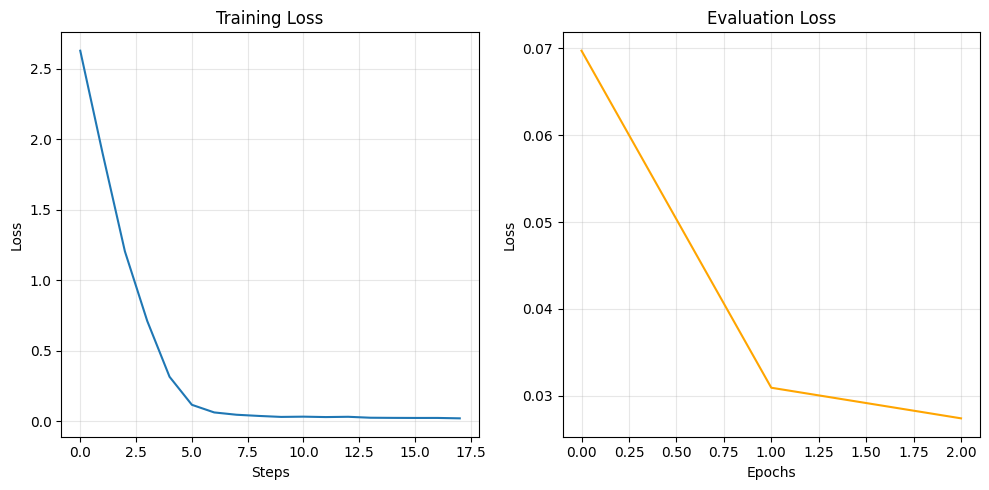

In [15]:
# Display training metrics
import matplotlib.pyplot as plt

# Extract loss from training history
train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

# Create loss plot
if train_loss or eval_loss:
    plt.figure(figsize=(10, 5))
    
    if train_loss:
        plt.subplot(1, 2, 1)
        plt.plot(train_loss)
        plt.title('Training Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
    
    if eval_loss:
        plt.subplot(1, 2, 2)
        plt.plot(eval_loss, 'orange')
        plt.title('Evaluation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Export Model

In [16]:
# Merge LoRA weights and save
merged_model = model.merge_and_unload()
merged_model.save_pretrained("./qwen3-function-calling-merged")
tokenizer.save_pretrained("./qwen3-function-calling-merged")

('./qwen3-function-calling-merged/tokenizer_config.json',
 './qwen3-function-calling-merged/special_tokens_map.json',
 './qwen3-function-calling-merged/chat_template.jinja',
 './qwen3-function-calling-merged/vocab.json',
 './qwen3-function-calling-merged/merges.txt',
 './qwen3-function-calling-merged/added_tokens.json',
 './qwen3-function-calling-merged/tokenizer.json')

## Inject Chat Template

Before converting to GGUF, we need to inject the proper chat template into the tokenizer configuration. This ensures the GGUF model has the correct chat format embedded for tool calling.

In [17]:
import json
from pathlib import Path
from transformers import AutoTokenizer

# IMPORTANT: Use the correct Qwen3 chat template for tool calling compatibility
# The original Qwen3 model has a proper chat template that supports tool calling
# We need to get this template and apply it to our merged model

print("🔧 Setting up correct chat template for tool calling...")

# Load the original Qwen3 tokenizer to get the correct chat template
print("Loading original Qwen3 tokenizer to extract correct chat template...")
original_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-1.7B', trust_remote_code=True)

# Get the correct chat template
correct_chat_template = original_tokenizer.chat_template
print(f"✅ Extracted correct Qwen3 chat template ({len(correct_chat_template)} characters)")

# Verify it supports tool calling
try:
    test_messages = [
        {'role': 'system', 'content': 'You are a helpful assistant.'},
        {'role': 'user', 'content': 'Hello'}
    ]
    test_tools = [{
        'type': 'function',
        'function': {
            'name': 'test_tool',
            'description': 'A test tool',
            'parameters': {'type': 'object', 'properties': {}}
        }
    }]
    
    # Test with tools
    formatted = original_tokenizer.apply_chat_template(
        test_messages,
        tools=test_tools,
        tokenize=False,
        add_generation_prompt=True
    )
    print("✅ Verified: Original Qwen3 chat template supports tool calling")
except Exception as e:
    print(f"❌ Warning: Chat template test failed: {e}")

# Create a clean version of the merged model with correct chat template
merged_model_path = "./qwen3-function-calling-merged"
clean_model_path = "./qwen3-function-calling-merged-clean"

print(f"Creating clean model with correct chat template: {clean_model_path}")

# Copy the merged model to clean directory
import shutil
if Path(clean_model_path).exists():
    shutil.rmtree(clean_model_path)
shutil.copytree(merged_model_path, clean_model_path)
print(f"✅ Copied merged model to {clean_model_path}")

# Update the tokenizer config with correct chat template
tokenizer_config_path = Path(clean_model_path) / "tokenizer_config.json"

with open(tokenizer_config_path, 'r') as f:
    config = json.load(f)

# Add the correct chat template
config['chat_template'] = correct_chat_template

# Save the updated config
with open(tokenizer_config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Updated tokenizer config with correct Qwen3 chat template")
print(f"Clean model ready at: {clean_model_path}")
print("\n🎯 This model will now work correctly with Strands and llama.cpp for tool calling!")

🔧 Setting up correct chat template for tool calling...
Loading original Qwen3 tokenizer to extract correct chat template...
✅ Extracted correct Qwen3 chat template (4168 characters)
✅ Verified: Original Qwen3 chat template supports tool calling
Creating clean model with correct chat template: ./qwen3-function-calling-merged-clean
✅ Copied merged model to ./qwen3-function-calling-merged-clean
✅ Updated tokenizer config with correct Qwen3 chat template
Clean model ready at: ./qwen3-function-calling-merged-clean

🎯 This model will now work correctly with Strands and llama.cpp for tool calling!


## Convert Model to GGUF Format

Convert the merged model to GGUF format for efficient edge deployment. GGUF (GPT-Generated Unified Format) is optimized for inference with llama.cpp, providing:

- **Quantization**: Reduce model size by 75% with minimal quality loss
- **Fast Loading**: Memory-mapped files for instant model loading
- **Cross-Platform**: Works on CPU, GPU, and edge devices
- **Production Ready**: Battle-tested inference engine

### Configure GGUF Conversion

Set up parameters for converting the fine-tuned model to GGUF format for edge deployment.

In [18]:
# GGUF conversion configuration
import subprocess
import shutil
from pathlib import Path

# Configuration - Use the CLEAN model with correct chat template
MODEL_NAME = "qwen3-function-calling-v1"
QUANTIZATION = "Q4_K_M"  # Good balance of size and quality
merged_model_path = "./qwen3-function-calling-merged-clean"  # Use clean model!
output_name = f"{MODEL_NAME}-{QUANTIZATION}.gguf"
source_tokenizer_dir = "./qwen3-function-calling-final"

print(f"Converting model to GGUF format")
print(f"Model: {MODEL_NAME}")
print(f"Quantization: {QUANTIZATION}")
print(f"Source: {merged_model_path}")

Converting model to GGUF format
Model: qwen3-function-calling-v1
Quantization: Q4_K_M
Source: ./qwen3-function-calling-merged-clean


In [19]:
# Execute GGUF conversion and quantization
model_dir = Path(merged_model_path)
gguf_dir = model_dir.with_name(model_dir.name + "-gguf")
gguf_dir.mkdir(parents=True, exist_ok=True)
gguf_path = gguf_dir / output_name

# Check for required tokenizer files and copy if needed
required_files = ["tokenizer.json", "vocab.json", "tokenizer_config.json"]
missing_files = [f for f in required_files if not (model_dir / f).exists()]

if missing_files and Path(source_tokenizer_dir).exists():
    print(f"Copying missing tokenizer files: {missing_files}")
    source_dir = Path(source_tokenizer_dir)
    for file in missing_files:
        source_file = source_dir / file
        if source_file.exists():
            shutil.copy2(source_file, model_dir / file)
            print(f"Copied: {file}")

# Verify conversion tools exist
convert_script = Path("./llama.cpp/convert_hf_to_gguf.py")
quantize_binary = Path("./llama.cpp/build/bin/llama-quantize")

if not convert_script.exists():
    print(f"Error: Conversion script not found at {convert_script}")
elif not quantize_binary.exists():
    print(f"Error: Quantization binary not found at {quantize_binary}")
else:
    # Step 1: Convert to FP16 GGUF
    temp_gguf = gguf_dir / "temp.gguf"
    print("Step 1: Converting to FP16 GGUF...")
    
    try:
        subprocess.run([
            "python", str(convert_script),
            str(model_dir),
            "--outfile", str(temp_gguf),
            "--outtype", "f16"
        ], check=True, capture_output=True, text=True)
        print("FP16 conversion successful")
        
        # Step 2: Quantize to target format
        print(f"Step 2: Quantizing to {QUANTIZATION}...")
        subprocess.run([
            str(quantize_binary),
            str(temp_gguf),
            str(gguf_path),
            QUANTIZATION
        ], check=True, capture_output=True, text=True)
        print(f"Quantization to {QUANTIZATION} successful")
        
        # Clean up temporary file
        if temp_gguf.exists():
            temp_gguf.unlink()
        
        # Verify output and report results
        if gguf_path.exists():
            file_size = gguf_path.stat().st_size / (1024**3)
            print(f"\nGGUF conversion completed successfully!")
            print(f"Output file: {gguf_path}")
            print(f"File size: {file_size:.2f} GB")
            print(f"Ready for llama.cpp deployment")
            
            # Store path for next steps
            GGUF_MODEL_PATH = str(gguf_path)
        else:
            print(f"Error: Output file not created at {gguf_path}")
            GGUF_MODEL_PATH = None
            
    except subprocess.CalledProcessError as e:
        print(f"Conversion failed: {e}")
        if e.stderr:
            print(f"Error details: {e.stderr}")
        # Clean up temp file if it exists
        if temp_gguf.exists():
            temp_gguf.unlink()
        GGUF_MODEL_PATH = None

Step 1: Converting to FP16 GGUF...
FP16 conversion successful
Step 2: Quantizing to Q4_K_M...
Quantization to Q4_K_M successful

GGUF conversion completed successfully!
Output file: qwen3-function-calling-merged-clean-gguf/qwen3-function-calling-v1-Q4_K_M.gguf
File size: 1.03 GB
Ready for llama.cpp deployment


## Model Evaluation

Compare the three model formats on tool calling accuracy and inference speed:
- **Raw Base Model**: Original Qwen3-1.7B without fine-tuning
- **Fine-tuned Model**: LoRA fine-tuned for function calling
- **GGUF Quantized Model**: Quantized version for edge deployment

In [20]:
# Setup for model evaluation
import time
import json
import re
import requests
import subprocess
import psutil
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
print(torch.cuda.is_available())

# Test cases for evaluation
TEST_CASES = [
    {
        "prompt": "Set the temperature to 72 degrees",
        "expected_tool": "climate_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "set_temperature", "temperature": 72}
    },
    {
        "prompt": "Open the driver side window", 
        "expected_tool": "window_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "open", "target": "driver"}
    },
    {
        "prompt": "Switch to sport mode",
        "expected_tool": "drive_mode",  # Correct: Use domain name as tool name
        "expected_args": {"action": "set_mode", "mode": "sport"}
    },
    {
        "prompt": "Turn on the headlights",
        "expected_tool": "lighting_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "set_headlights", "headlight_mode": "on"}
    },
    {
        "prompt": "Move seat forward",
        "expected_tool": "seat_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "adjust_position", "seat": "driver", "position_type": "forward", "adjustment": 10}
    },
    {
        "prompt": "Close all windows",
        "expected_tool": "window_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "close", "target": "all"}
    },
    {
        "prompt": "Turn on seat heating",
        "expected_tool": "seat_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "set_heating", "seat": "driver", "heating_level": 2}
    },
    {
        "prompt": "Set ambient lighting to blue",
        "expected_tool": "lighting_control",  # Correct: Use domain name as tool name
        "expected_args": {"action": "set_ambient", "ambient_color": "blue", "ambient_brightness": 60}
    }
]

print(f"Loaded {len(TEST_CASES)} test cases for evaluation")

True
Loaded 8 test cases for evaluation


## Model Evaluation Setup

Set up test cases and helper functions for evaluating model performance across different formats.

In [21]:
# Load tools dynamically from cockpit agents
print("Loading tools from cockpit agents...")
from agents.cockpit import climate_control, window_control, seat_control, lighting_control, drive_mode

cockpit_tools = [climate_control.tool_spec, window_control.tool_spec, seat_control.tool_spec, lighting_control.tool_spec, drive_mode.tool_spec]

# JSON payload template for function calling evaluation
# This will be used with the Jinja template to generate prompts
PROMPT_JSON_TEMPLATE = {
    "messages": [
        {
            "role": "system",
            "content": "You are a helpful AI assistant with access to various vehicle control tools. Use them to help users effectively. You will be provided with function signatures within <tools></tools> XML tags. For each function call, return a json object with function name and arguments within <tool_call>{'name': <function-name>, 'arguments': <args-json-object>}</tool_call> XML tags./no_think"
        },
        {
            "role": "user",
            "content": "{user_message}"
        }
    ],
    "tools": cockpit_tools,  # Use dynamically loaded tools
    "add_generation_prompt": True,
    "enable_thinking": False
}

Loading tools from cockpit agents...


In [22]:
# Helper functions for evaluation
import re
import json
import time
import psutil
import jinja2
import copy
import sys
import os
from typing import Dict, List, Any
import inspect

# Load the Jinja template for chat formatting
def load_chat_template():
    templateLoader = jinja2.FileSystemLoader(searchpath="./utils")
    templateEnv = jinja2.Environment(loader=templateLoader)
    template = templateEnv.get_template("chat_template.jinja")
    return template

# Function to generate prompt using Jinja template
def generate_prompt_from_json(template, json_payload, user_message):
    # Create a copy of the template and substitute the user message
    payload = copy.deepcopy(json_payload)
    for message in payload['messages']:
        if message['role'] == 'user':
            message['content'] = message['content'].format(user_message=user_message)
    
    # Render the template
    return template.render(**payload)

# Extract tool call from model response
def extract_tool_call(response):
    try:
        # DEBUG: Print what we're trying to extract
        print(f"[extract_tool_call] Looking for <tool_call> tags in: {repr(response[:200])}...")
        
        match = re.search(r'<tool_call>(.*?)</tool_call>', response, re.DOTALL)
        if not match:
            print(f"[extract_tool_call] No <tool_call> tags found")
            return None, None
        
        tool_json_str = match.group(1).strip()
        print(f"[extract_tool_call] Found tool_call content: {repr(tool_json_str)}")
        
        tool_json = json.loads(tool_json_str)
        tool_name = tool_json.get('name')
        tool_args = tool_json.get('arguments')
        
        print(f"[extract_tool_call] Parsed - name: {tool_name}, args: {tool_args}")
        return tool_name, tool_args
    except Exception as e:
        print(f"[extract_tool_call] Exception: {e}")
        return None, None

# Measure current memory usage
def measure_memory_usage():
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def convert_strands_to_openai_tool(strands_tool):
    """Convert Strands tool format to OpenAI function format.
    
    This function converts the Strands tool_spec format to the OpenAI
    function calling format used by chat completions API.
    
    Args:
        strands_tool: Tool spec with 'name', 'description', and 'inputSchema' fields
        
    Returns:
        dict: OpenAI-compatible tool definition
    """
    return {
        "type": "function",
        "function": {
            "name": strands_tool["name"],
            "description": strands_tool["description"],
            "parameters": strands_tool["inputSchema"]["json"]
        }
    }

# Convert all cockpit tools to OpenAI format for API-based evaluations
# (Used by GGUF evaluation with llama.cpp server)
openai_tools = [convert_strands_to_openai_tool(tool) for tool in cockpit_tools]

print("Evaluation setup complete")
print(f"Loaded {len(cockpit_tools)} tools and converted to OpenAI format")
print("Note: Raw/Fine-tuned models use Jinja templates, GGUF uses OpenAI format")

Evaluation setup complete
Loaded 5 tools and converted to OpenAI format
Note: Raw/Fine-tuned models use Jinja templates, GGUF uses OpenAI format


## Raw Base Model Evaluation

Evaluate the performance of the raw Qwen3-1.7B base model on function calling tasks.

In [23]:
# Evaluate raw base model performance
print("Loading raw base model...")
start_mem = measure_memory_usage()

# Check CUDA availability and force GPU usage
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load raw base model with explicit device mapping
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B",
    torch_dtype=torch.float16,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True
)

# If device_map="auto" didn't work, manually move to GPU
if torch.cuda.is_available() and base_model.device.type == "cpu":
    print("Moving model to GPU manually...")
    base_model = base_model.to(device)

print(f"Model device: {base_model.device}")

base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", trust_remote_code=True)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

load_mem = measure_memory_usage()

# Initialize results tracking
raw_results = {
    "model_type": "Raw Base Model",
    "memory_usage_mb": load_mem - start_mem,
    "test_results": [],
    "total_time": 0,
    "accuracy": 0
}

base_model.eval()
correct_predictions = 0
total_time = 0

print(f"Model loaded. Memory usage: {raw_results['memory_usage_mb']:.0f} MB")
print("\nRunning evaluation tests...")

# Load chat template for prompt generation
chat_template = load_chat_template()
print("Chat template loaded")

# Run evaluation on test cases
for i, test_case in enumerate(TEST_CASES):
    # Generate prompt using Jinja template and JSON payload
    # prompt = generate_prompt_from_json(chat_template, PROMPT_JSON_TEMPLATE, test_case["prompt"])
    prompt = copy.deepcopy(PROMPT_JSON_TEMPLATE)
    print("RAW PROMPT:",prompt)
    # Update user message in the JSON payload
    for message in prompt['messages']:
        if message['role'] == 'user':
            message['content'] = message['content'].format(user_message=test_case["prompt"])
    prompt = base_tokenizer.apply_chat_template(
        prompt['messages'],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
        tools=prompt['tools']
    )
    print(f"Formatted Prompt: {prompt}")
    
    # Tokenize input
    inputs = base_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(base_model.device) for k, v in inputs.items()}
    
    # Verify device placement
    print(f"Input tensors device: {inputs['input_ids'].device}")
    print(f"Model device: {base_model.device}")
    
    # Time inference
    start_time = time.time()
    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=5000,
            temperature=0.1,
            do_sample=False,
            pad_token_id=base_tokenizer.pad_token_id
        )
    inference_time = time.time() - start_time
    total_time += inference_time
    
    # Decode response
    response = base_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
    
    # Extract tool call
    tool_name, tool_args = extract_tool_call(response)
    
    # DEBUG: Print raw response and extraction results
    print(f"\n=== RAW BASE MODEL DEBUG - Test {i+1} ===")
    print(f"Prompt: {test_case['prompt']}")
    print(f"Raw Response: {repr(response)}")
    print(f"Raw Response (readable): {response}")
    print(f"Extracted tool_name: {tool_name}")
    print(f"Extracted tool_args: {tool_args}")
    print("=" * 50)
    
    # Check accuracy
    is_correct = tool_name == test_case["expected_tool"]
    if is_correct:
        correct_predictions += 1
    
    # Store results
    raw_results["test_results"].append({
        "test_case": test_case["prompt"],
        "expected_tool": test_case["expected_tool"],
        "predicted_tool": tool_name,
        "correct": is_correct,
        "inference_time_ms": inference_time * 1000,
        "response": response,
        "full_response": response
    })
    
    # Print test result
    status = "PASS" if is_correct else "FAIL"
    print(f"  Test {i+1}/5: {status} - {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
    if not is_correct:
        print(f"    Expected: {test_case['expected_tool']}")
        print(f"    Got: {tool_name or 'None'}")

# Calculate final metrics
raw_results["accuracy"] = correct_predictions / len(TEST_CASES)
raw_results["total_time"] = total_time
raw_results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000

print(f"\nRaw model evaluation complete:")
print(f"  Accuracy: {raw_results['accuracy']:.1%}")
print(f"  Average inference time: {raw_results['avg_time_ms']:.0f}ms")
print(f"  Memory usage: {raw_results['memory_usage_mb']:.0f}MB")

# Clean up
del base_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading raw base model...
Using device: cuda


2025-08-29 18:46:59,137 - accelerate.utils.modeling - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

[extract_tool_call] Looking for <tool_call> tags in: '-85) for set_temperature", "type": "number"}, "temperature_adjustment": {"default": null, "description": "Temperature change in degrees (-10 to +10) for adjust_temperature", "type": "number"}, "fan_sp'...
[extract_tool_call] No <tool_call> tags found

=== RAW BASE MODEL DEBUG - Test 5 ===
Prompt: Move seat forward
Raw Response: '-85) for set_temperature", "type": "number"}, "temperature_adjustment": {"default": null, "description": "Temperature change in degrees (-10 to +10) for adjust_temperature", "type": "number"}, "fan_speed": {"default": null, "description": "Fan speed level (0-7) for set_fan_speed", "type": "number"}, "fan_adjustment": {"default": null, "description": "Fan speed change (-3 to +3) for adjust_fan_speed", "type": "number"}, "mode": {"default": null, "description": "Climate mode for set_mode (\\"auto\\", \\"heat\\", \\"cool\\", \\"defrost\\", \\"vent\\")", "type": "string"}, "enable": {"default": null, "descriptio

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[extract_tool_call] Looking for <tool_call> tags in: '-85) for set_temperature", "type": "number"}, "temperature_adjustment": {"default": null, "description": "Temperature change in degrees (-10 to +10) for adjust_temperature", "type": "number"}, "fan_sp'...
[extract_tool_call] No <tool_call> tags found

=== RAW BASE MODEL DEBUG - Test 6 ===
Prompt: Close all windows
Raw Response: '-85) for set_temperature", "type": "number"}, "temperature_adjustment": {"default": null, "description": "Temperature change in degrees (-10 to +10) for adjust_temperature", "type": "number"}, "fan_speed": {"default": null, "description": "Fan speed level (0-7) for set_fan_speed", "type": "number"}, "fan_adjustment": {"default": null, "description": "Fan speed change (-3 to +3) for adjust_fan_speed", "type": "number"}, "mode": {"default": null, "description": "Climate mode for set_mode (\\"auto\\", \\"heat\\", \\"cool\\", \\"defrost\\", \\"vent\\")", "type": "string"}, "enable": {"default": null, "descriptio

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[extract_tool_call] Looking for <tool_call> tags in: '-85) for set_temperature", "type": "number"}, "temperature_adjustment": {"default": null, "description": "Temperature change in degrees (-10 to +10) for adjust_temperature", "type": "number"}, "fan_sp'...
[extract_tool_call] No <tool_call> tags found

=== RAW BASE MODEL DEBUG - Test 7 ===
Prompt: Turn on seat heating
Raw Response: '-85) for set_temperature", "type": "number"}, "temperature_adjustment": {"default": null, "description": "Temperature change in degrees (-10 to +10) for adjust_temperature", "type": "number"}, "fan_speed": {"default": null, "description": "Fan speed level (0-7) for set_fan_speed", "type": "number"}, "fan_adjustment": {"default": null, "description": "Fan speed change (-3 to +3) for adjust_fan_speed", "type": "number"}, "mode": {"default": null, "description": "Climate mode for set_mode (\\"auto\\", \\"heat\\", \\"cool\\", \\"defrost\\", \\"vent\\")", "type": "string"}, "enable": {"default": null, "descrip

## GGUF Model Evaluation

Evaluate the performance of the quantized GGUF model using llama.cpp server.

**Updated Methodology**: This evaluation now uses the OpenAI-compatible chat completions API endpoint (`/v1/chat/completions`) with proper tool calling format, matching the production implementation in `evaluate_gguf_model.py`. This approach:

- Uses the same OpenAI format that Strands agents use successfully
- Leverages the embedded Jinja chat template for proper tool calling
- Converts Strands tool definitions to OpenAI function format
- Parses structured tool calls from the response

This ensures the evaluation accurately reflects real-world usage patterns.

In [24]:
# GGUF Model Evaluation Setup
import subprocess
import requests
import signal
import os
import json
from pathlib import Path

# GGUF model path - updated to match current implementation
gguf_path = "./qwen3-function-calling-merged-clean-gguf/qwen3-function-calling-v1-Q4_K_M.gguf"
server_port = 8081

# Check if GGUF file exists
if not Path(gguf_path).exists():
    print(f"GGUF file not found: {gguf_path}")
    print("Skipping GGUF evaluation")
    gguf_results = None
else:
    print(f"Starting GGUF server on port {server_port}...")
    
    # Start llama.cpp server with embedded chat template for proper tool calling
    server_cmd = [
        "./llama.cpp/build/bin/llama-server",
        "-m", gguf_path,
        "--port", str(server_port),
        "--host", "0.0.0.0",
        "--jinja"  # Use embedded Jinja template for tool calling
    ]
    print(f"Server command: {' '.join(server_cmd)}")
    
    try:
        # Start server process
        server_process = subprocess.Popen(
            server_cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            preexec_fn=os.setsid
        )
        
        # Wait for server to be ready
        import time
        max_wait = 30
        wait_time = 0
        server_ready = False
        
        print("Waiting for server to start...")
        while wait_time < max_wait:
            try:
                response = requests.get(f"http://localhost:{server_port}/health", timeout=2)
                if response.status_code == 200:
                    server_ready = True
                    break
            except:
                pass
            time.sleep(1)
            wait_time += 1
            print(f"  Waiting... ({wait_time}/{max_wait}s)")
        
        if not server_ready:
            print("Server failed to start within timeout")
            gguf_results = None
        else:
            print("Server ready, starting evaluation...")
            
            # Initialize results tracking
            gguf_results = {
                "model_type": "GGUF Quantized Model",
                "memory_usage_mb": "N/A (External Server)",
                "test_results": [],
                "total_time": 0,
                "accuracy": 0
            }
            
            correct_predictions = 0
            total_time = 0
            
            print("\nRunning GGUF evaluation tests...")

            # Use the shared OpenAI tools from evaluation setup
            # (Tools were already converted in the Model Evaluation Setup section)
            
            # Run evaluation on test cases
            for i, test_case in enumerate(TEST_CASES):
                print(f"\nProcessing test {i+1}/{len(TEST_CASES)}: {test_case['prompt']}")
                
                # Use the same OpenAI format that Strands uses successfully
                payload = {
                    "model": "qwen3",
                    "messages": [
                        {
                            "role": "system",
                            "content": "You are a helpful assistant with access to vehicle control tools."
                        },
                        {
                            "role": "user",
                            "content": test_case["prompt"]
                        }
                    ],
                    "tools": openai_tools,
                    "temperature": 0.1,
                    "max_tokens": 200,
                    "stream": False
                }
                
                # Time inference
                start_time = time.time()
                try:
                    response = requests.post(
                        f"http://localhost:{server_port}/v1/chat/completions",
                        json=payload,
                        timeout=60
                    )
                    response.raise_for_status()
                    result = response.json()
                    
                    # Parse OpenAI chat completions response format
                    choice = result.get("choices", [{}])[0]
                    message = choice.get("message", {})
                    tool_calls = message.get("tool_calls", [])
                    response_text = message.get("content", "")
                    
                    # Extract tool call from OpenAI format
                    if tool_calls:
                        tool_call = tool_calls[0]  # Take first tool call
                        function = tool_call.get("function", {})
                        tool_name = function.get("name", "")
                        try:
                            tool_args = json.loads(function.get("arguments", "{}"))
                        except:
                            tool_args = {}
                    else:
                        tool_name = ""
                        tool_args = {}
                        
                except Exception as e:
                    print(f"    Request failed: {e}")
                    response_text = ""
                    tool_name = ""
                    tool_args = {}
                    result = {}
                    tool_calls = []
                
                inference_time = time.time() - start_time
                total_time += inference_time
                
                # DEBUG: Print raw response and extraction results
                print(f"\n=== GGUF MODEL DEBUG - Test {i+1} ===")
                print(f"Prompt: {test_case['prompt']}")
                if 'result' in locals():
                    print(f"Full API Response: {result}")
                print(f"Response Text: {response_text}")
                print(f"Tool Calls: {tool_calls if 'tool_calls' in locals() else 'None'}")
                print(f"Extracted tool_name: {tool_name}")
                print(f"Extracted tool_args: {tool_args}")
                print("=" * 50)
                
                # Check accuracy
                is_correct = tool_name == test_case["expected_tool"]
                if is_correct:
                    correct_predictions += 1
                
                # Store results
                gguf_results["test_results"].append({
                    "test_case": test_case["prompt"],
                    "expected_tool": test_case["expected_tool"],
                    "predicted_tool": tool_name,
                    "predicted_args": tool_args,
                    "correct": is_correct,
                    "inference_time_ms": inference_time * 1000,
                    "response_text": response_text,
                    "tool_calls": tool_calls if 'tool_calls' in locals() else []
                })
                
                # Print test result
                status = "PASS" if is_correct else "FAIL"
                print(f"  Test {i+1}/5: {status} - {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
                if not is_correct:
                    print(f"    Expected: {test_case['expected_tool']}")
                    print(f"    Got: {tool_name or 'None'}")
            
            # Calculate final metrics
            gguf_results["accuracy"] = correct_predictions / len(TEST_CASES)
            gguf_results["total_time"] = total_time
            gguf_results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000
            
            print(f"\nGGUF model evaluation complete:")
            print(f"  Accuracy: {gguf_results['accuracy']:.1%}")
            print(f"  Average inference time: {gguf_results['avg_time_ms']:.0f}ms")
        
    except Exception as e:
        print(f"GGUF evaluation failed: {e}")
        gguf_results = None
    
    finally:
        # Clean up server
        if 'server_process' in locals():
            print("Stopping GGUF server...")
            try:
                os.killpg(os.getpgid(server_process.pid), signal.SIGTERM)
                server_process.wait(timeout=5)
            except:
                pass

Starting GGUF server on port 8081...
Server command: ./llama.cpp/build/bin/llama-server -m ./qwen3-function-calling-merged-clean-gguf/qwen3-function-calling-v1-Q4_K_M.gguf --port 8081 --host 0.0.0.0 --jinja
Waiting for server to start...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Waiting... (1/30s)
  Waiting... (2/30s)
Server ready, starting evaluation...

Running GGUF evaluation tests...

Processing test 1/8: Set the temperature to 72 degrees

=== GGUF MODEL DEBUG - Test 1 ===
Prompt: Set the temperature to 72 degrees
Full API Response: {'choices': [{'finish_reason': 'tool_calls', 'index': 0, 'message': {'role': 'assistant', 'content': None, 'tool_calls': [{'type': 'function', 'function': {'name': 'climate_control', 'arguments': '{"action":"set_temperature","temperature":72}'}, 'id': 'oSSFtVuZIt1owsOC3WHjWRm46maiCrVH'}]}}], 'created': 1756494512, 'model': 'qwen3', 'system_fingerprint': 'b6319-792b44f2', 'object': 'chat.completion', 'usage': {'completion_tokens': 38, 'prompt_tokens': 2842, 'total_tokens': 2880}, 'id': 'chatcmpl-SY5x8IjVKbIikIWQ0QhYFwZYkWWn09zN', 'timings': {'prompt_n': 2842, 'prompt_ms': 38687.575, 'prompt_per_token_ms': 13.6127990851513, 'prompt_per_second': 73.46027762143272, 'predicted_n': 38, 'predicted_ms': 2077.65, 'predicted_per_token_

## Results Comparison

Compare the performance of all three model formats side by side.

In [25]:
# Compare results from all model evaluations
print("Model Evaluation Results Comparison")
print("=" * 50)

# Collect all results
all_results = []
if 'raw_results' in locals():
    all_results.append(raw_results)
if 'gguf_results' in locals() and gguf_results is not None:
    all_results.append(gguf_results)

if not all_results:
    print("No evaluation results available for comparison")
else:
    # Summary table
    print(f"{'Model Type':<25} {'Accuracy':<10} {'Avg Time (ms)':<15} {'Memory (MB)':<12}")
    print("-" * 70)
    
    for result in all_results:
        model_type = result['model_type']
        accuracy = f"{result['accuracy']:.1%}"
        avg_time = f"{result['avg_time_ms']:.0f}ms"
        memory = str(result['memory_usage_mb']) if isinstance(result['memory_usage_mb'], str) else f"{result['memory_usage_mb']:.0f}"
        
        print(f"{model_type:<25} {accuracy:<10} {avg_time:<15} {memory:<12}")
    
    # Performance insights
    print("\nKey Insights:")
    print("-" * 20)
    
    if len(all_results) >= 2:
        best_accuracy = max(r['accuracy'] for r in all_results)
        fastest_time = min(r['avg_time_ms'] for r in all_results)
        
        print(f"Best accuracy: {best_accuracy:.1%}")
        print(f"Fastest inference: {fastest_time:.0f}ms average")
        
        # Find best performing models
        best_accuracy_model = next(r for r in all_results if r['accuracy'] == best_accuracy)
        fastest_model = next(r for r in all_results if r['avg_time_ms'] == fastest_time)
        
        print(f"Most accurate model: {best_accuracy_model['model_type']}")
        print(f"Fastest model: {fastest_model['model_type']}")
    
    # Detailed test results
    print("\nDetailed Test Results:")
    print("-" * 30)
    
    for i, test_case in enumerate(TEST_CASES):
        print(f"\nTest {i+1}: {test_case['prompt']}")
        print(f"Expected: {test_case['expected_tool']}")
        
        for result in all_results:
            if i < len(result['test_results']):
                test_result = result['test_results'][i]
                status = "PASS" if test_result['correct'] else "FAIL"
                predicted = test_result['predicted_tool'] or "None"
                time_ms = test_result['inference_time_ms']
                
                print(f"  {result['model_type']:<25} {status:<4} {predicted:<15} ({time_ms:.0f}ms)")

print("\nEvaluation complete!")

Model Evaluation Results Comparison
Model Type                Accuracy   Avg Time (ms)   Memory (MB) 
----------------------------------------------------------------------
Raw Base Model            0.0%       156078ms        34          
GGUF Quantized Model      100.0%     7341ms          N/A (External Server)

Key Insights:
--------------------
Best accuracy: 100.0%
Fastest inference: 7341ms average
Most accurate model: GGUF Quantized Model
Fastest model: GGUF Quantized Model

Detailed Test Results:
------------------------------

Test 1: Set the temperature to 72 degrees
Expected: climate_control
  Raw Base Model            FAIL None            (156611ms)
  GGUF Quantized Model      PASS climate_control (40795ms)

Test 2: Open the driver side window
Expected: window_control
  Raw Base Model            FAIL None            (156213ms)
  GGUF Quantized Model      PASS window_control  (2206ms)

Test 3: Switch to sport mode
Expected: drive_mode
  Raw Base Model            FAIL None     

## Upload GGUF Model to S3

Upload the production-ready GGUF model to S3 for fast edge deployment.
GGUF files are optimized for edge inference and much smaller than full model directories.


In [26]:
# Upload GGUF model to S3 for edge deployment
import boto3
from pathlib import Path
from botocore.exceptions import ClientError, NoCredentialsError

boto3_session = boto3.session.Session()
aws_account_id = boto3.client("sts").get_caller_identity()["Account"]

# Configuration - Update these values for your deployment
S3_BUCKET_NAME = f"automotive-workshop-{aws_account_id}-{boto3_session.region_name}"  # Replace with your bucket name
S3_KEY = "gguf-models/qwen3-function-calling-v1-Q4_K_M.gguf"  # S3 path for the model
GGUF_FILE_PATH = "./qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf"

print("Uploading GGUF Model to S3")
print("=" * 40)

try:
    # Initialize S3 client
    s3_client = boto3.client('s3')
    
    # Check if GGUF file exists
    gguf_path = Path(GGUF_FILE_PATH)
    if not gguf_path.exists():
        print(f"GGUF file not found: {GGUF_FILE_PATH}")
        print("Please ensure the GGUF conversion step completed successfully.")
    else:
        # Get file size for progress reporting
        file_size_mb = gguf_path.stat().st_size / 1024 / 1024
        print(f"File: {gguf_path.name}")
        print(f"Size: {file_size_mb:.1f} MB")
        print(f"Destination: s3://{S3_BUCKET_NAME}/{S3_KEY}")
        
        # Check if bucket is accessible
        try:
            s3_client.head_bucket(Bucket=S3_BUCKET_NAME)
            print(f"S3 bucket '{S3_BUCKET_NAME}' is accessible")
        except ClientError as e:
            error_code = e.response['Error']['Code']
            if error_code == '404':
                print(f"Bucket '{S3_BUCKET_NAME}' does not exist")
                print("Please create the bucket or update S3_BUCKET_NAME")
                raise
            else:
                print(f"Error accessing bucket: {e}")
                raise
        
        # Upload the file
        print("\nStarting upload...")
        s3_client.upload_file(
            str(gguf_path),
            S3_BUCKET_NAME,
            S3_KEY,
            ExtraArgs={
                'ContentType': 'application/octet-stream',
                'ServerSideEncryption': 'AES256'
            }
        )
        
        print("Upload completed successfully!")
        print(f"\nModel Details:")
        print(f"  S3 Location: s3://{S3_BUCKET_NAME}/{S3_KEY}")
        print(f"  File Size: {file_size_mb:.1f} MB")
        print(f"  Format: Q4_K_M quantized GGUF")
        print(f"  Compatible with: llama.cpp, Ollama, LM Studio")
        print(f"\nThe model is now ready for edge deployment!")

except NoCredentialsError:
    print("AWS credentials not found.")
    print("Please configure your AWS credentials using:")
    print("  - AWS CLI: aws configure")
    print("  - Environment variables: AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY")
    print("  - IAM roles (if running on EC2)")

except Exception as e:
    print(f"Upload failed: {e}")
    print("\nTroubleshooting:")
    print("  1. Verify AWS credentials are configured")
    print("  2. Check S3 bucket name and permissions")
    print("  3. Ensure GGUF file exists and is accessible")

2025-08-29 19:08:51,030 - botocore.credentials - INFO - Found credentials from IAM Role: AWSCloud9SSMAccessRole


Uploading GGUF Model to S3
GGUF file not found: ./qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf
Please ensure the GGUF conversion step completed successfully.
